<a href="https://colab.research.google.com/github/gauridhepe21-glitch/Python_AIML_Lab/blob/main/Assignment19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [3]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Create a categorical column for countplot & encoding
df["Income_Level"] = pd.cut(
    df["MedInc"],
    bins=[0,2,4,6,8,20],
    labels=["Very Low","Low","Medium","High","Very High"]
)

print("First 10 Rows")
print(df.head(10))


First 10 Rows
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
5  4.0368      52.0  4.761658   1.103627       413.0  2.139896     37.85   
6  3.6591      52.0  4.931907   0.951362      1094.0  2.128405     37.84   
7  3.1200      52.0  4.797527   1.061824      1157.0  1.788253     37.84   
8  2.0804      42.0  4.294118   1.117647      1206.0  2.026891     37.84   
9  3.6912      52.0  4.970588   0.990196      1551.0  2.172269     37.84   

   Longitude  MedHouseVal Income_Level  
0    -122.23        4.526    Very High  
1    -122.22        3.585    Very High  
2    -122.24        3.521 

In [4]:
print("\nMissing Values")
missing = df.isnull().sum()
percentage = (missing/len(df))*100

missing_df = pd.DataFrame({
    "Missing": missing,
    "Percentage": percentage
})

print(missing_df)


Missing Values
              Missing  Percentage
MedInc              0         0.0
HouseAge            0         0.0
AveRooms            0         0.0
AveBedrms           0         0.0
Population          0         0.0
AveOccup            0         0.0
Latitude            0         0.0
Longitude           0         0.0
MedHouseVal         0         0.0
Income_Level        0         0.0


In [5]:
df.fillna(df.median(numeric_only=True), inplace=True)

# Remove duplicates
duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

df.drop_duplicates(inplace=True)


Duplicate Rows: 0


In [6]:
print("\nStatistical Summary")
print(df.describe())

print("\nTarget Variable Statistics")
print("Minimum :", df["MedHouseVal"].min())
print("Maximum :", df["MedHouseVal"].max())
print("Mean    :", df["MedHouseVal"].mean())
print("Median  :", df["MedHouseVal"].median())



Statistical Summary
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        

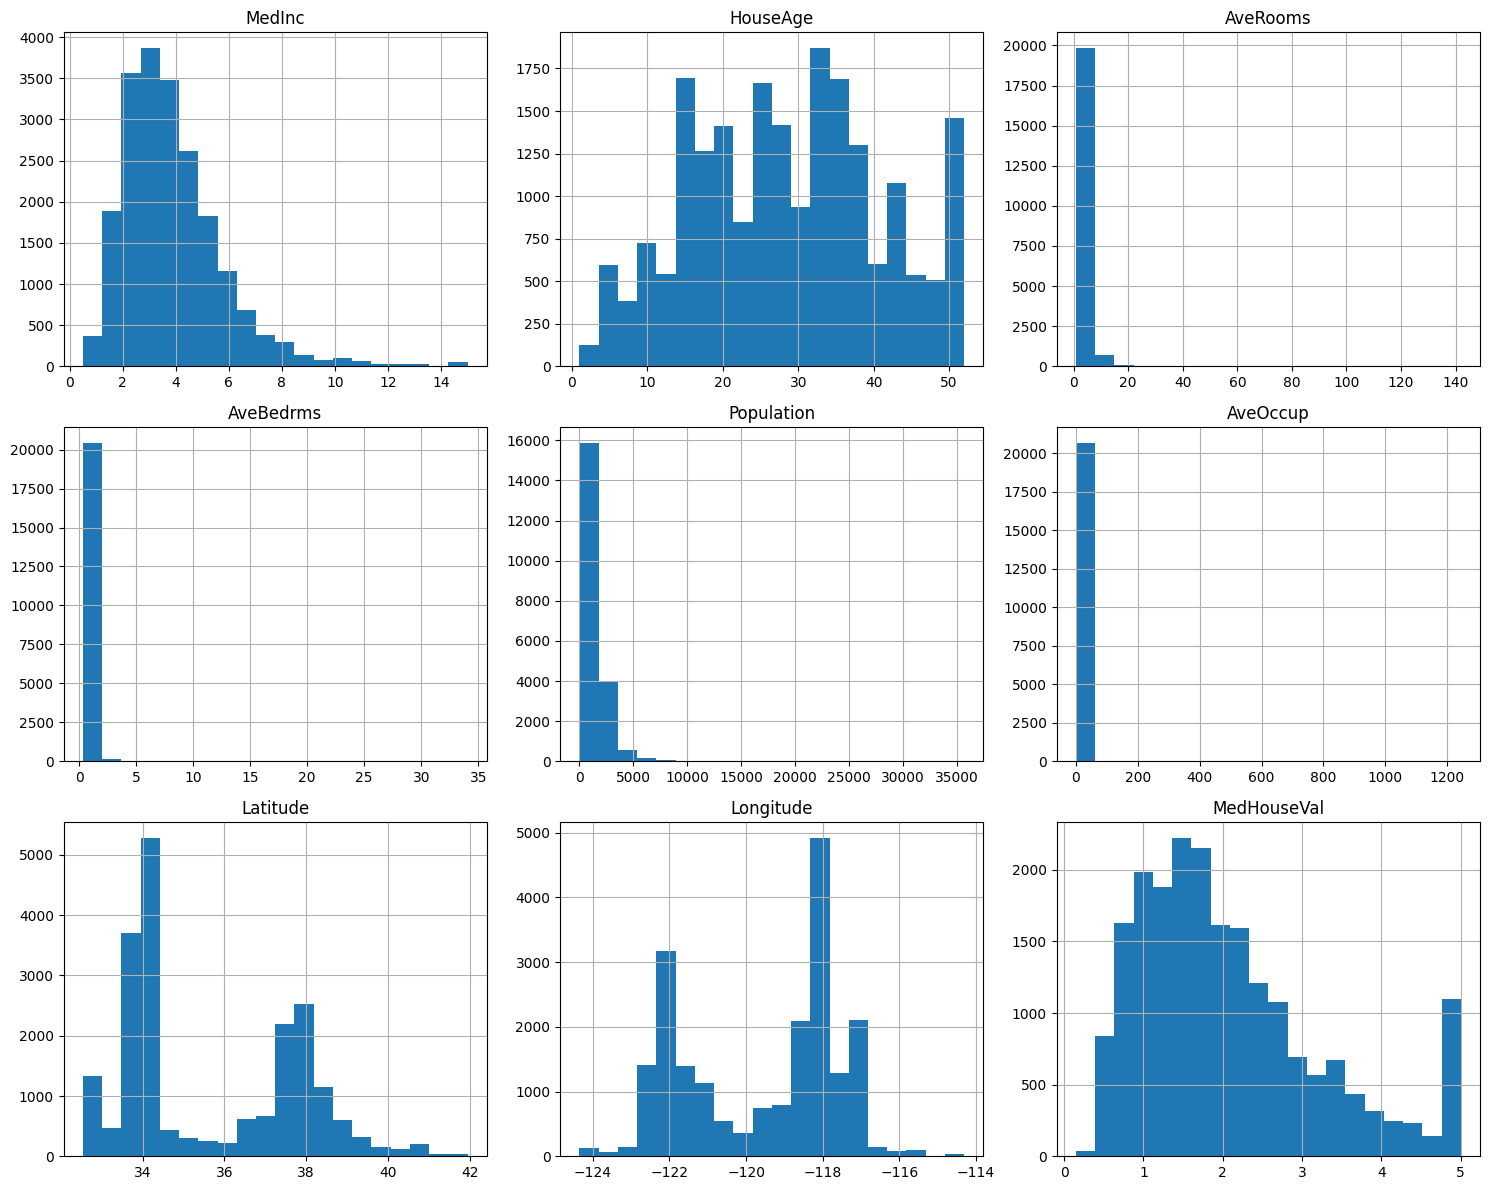

In [7]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()


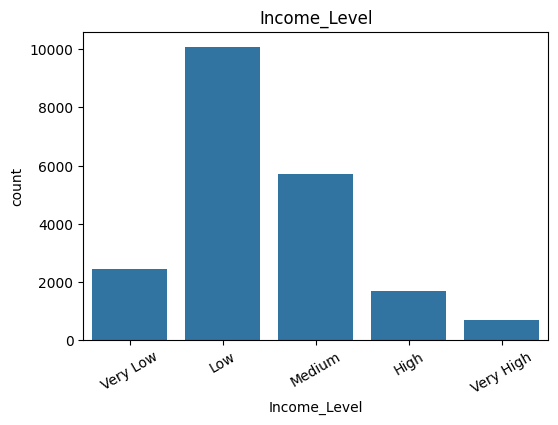

In [8]:
categorical_columns = df.select_dtypes(include="category").columns

for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.xticks(rotation=30)
    plt.title(col)
    plt.show()

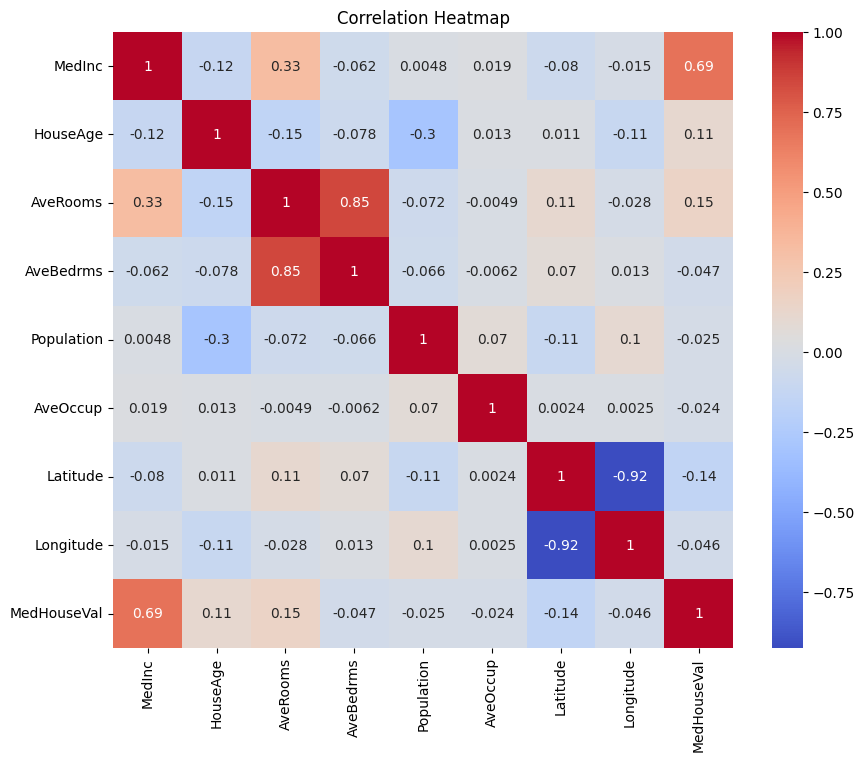

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_columns].corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
print("\nCorrelation with Target Variable")
print(df[numeric_columns].corr()["MedHouseVal"].sort_values(ascending=False))



Correlation with Target Variable
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [11]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("\nIndependent Features")
print(X.columns)

print("\nDependent Feature")
print(y.name)



Independent Features
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Income_Level'],
      dtype='object')

Dependent Feature
MedHouseVal


In [12]:
print("\nBefore Encoding")
print(df[["Income_Level"]].head())

encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df[["Income_Level"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["Income_Level"])
)

df = pd.concat([df.drop("Income_Level", axis=1),
                encoded_df],
               axis=1)

print("\nAfter Encoding")
print(df.head())



Before Encoding
  Income_Level
0    Very High
1    Very High
2         High
3       Medium
4          Low

After Encoding
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  Income_Level_High  Income_Level_Low  \
0    -122.23        4.526                0.0               0.0   
1    -122.22        3.585                0.0               0.0   
2    -122.24        3.521                1.0               0.0   
3    -122.25        3.413                0.0               0.0   
4    -122.25        3.422                0.0               1.0   

   Income_Level_Medium 

In [13]:
X = df.drop("MedHouseVal", axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("\nFirst 5 Rows of Scaled Data")
print(scaled_df.head())



First 5 Rows of Scaled Data
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  2.344766  0.982143  0.628559  -0.153758   -0.974429 -0.049597  1.052548   
1  2.332238 -0.607019  0.327041  -0.263336    0.861439 -0.092512  1.043185   
2  1.782699  1.856182  1.155620  -0.049016   -0.820777 -0.025843  1.038503   
3  0.932968  1.856182  0.156966  -0.049833   -0.766028 -0.050329  1.038503   
4 -0.012881  1.856182  0.344711  -0.032906   -0.759847 -0.085616  1.038503   

   Longitude  Income_Level_High  Income_Level_Low  Income_Level_Medium  \
0  -1.327835          -0.296898         -0.978525            -0.619550   
1  -1.322844          -0.296898         -0.978525            -0.619550   
2  -1.332827           3.368159         -0.978525            -0.619550   
3  -1.337818          -0.296898         -0.978525             1.614076   
4  -1.337818          -0.296898          1.021946            -0.619550   

   Income_Level_Very High  Income_Level_Very Low  
0     

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Features (X) and target (y)
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]  # Continuous target variable (median house value)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.5558915986952444
